# Notebook 3: Modeling

## Stock Price Forecasting Application

---

**Objective:** Train multiple machine learning models to predict the next-day closing price for AAPL stock, using the preprocessed features from Notebook 02.

**Models Selected:**

| # | Model | Rationale |
|---|-------|-----------|
| 1 | **Linear Regression** | Simple baseline; assumes linear relationship between features and target |
| 2 | **Random Forest Regressor** | Ensemble method; captures non-linear relationships; robust to outliers |
| 3 | **XGBoost Regressor** | Gradient boosting; typically state-of-the-art for tabular data |
| 4 | **LSTM Neural Network** | Recurrent architecture designed for sequential/temporal data |

**Algorithm Selection Rationale:**
- We chose a diverse set of algorithms spanning parametric (Linear Regression), ensemble (Random Forest, XGBoost), and deep learning (LSTM) categories.
- This breadth allows us to compare fundamentally different approaches and identify which captures stock price dynamics most effectively.
- All models are supervised learning regression algorithms, appropriate for our continuous target variable (next-day closing price).

## 3.1 Import Libraries and Load Data

In [3]:
import sys
import os

# Ensure venv_ml packages are available (TensorFlow installed there due to path-length constraints)
venv_site = r'C:\venv_ml\Lib\site-packages'
if venv_site not in sys.path:
    sys.path.insert(0, venv_site)

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-whitegrid')

print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported successfully.')

TensorFlow version: 2.21.0
All libraries imported successfully.


In [4]:
# Load preprocessed data
data_dir = os.path.join('..', 'data')
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'), index_col='Date', parse_dates=True)
X_test = pd.read_csv(os.path.join(data_dir, 'X_test.csv'), index_col='Date', parse_dates=True)
y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv'), index_col='Date', parse_dates=True).squeeze()
y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv'), index_col='Date', parse_dates=True).squeeze()

X_train_scaled = pd.read_csv(os.path.join(data_dir, 'X_train_scaled.csv'), index_col='Date', parse_dates=True)
X_test_scaled = pd.read_csv(os.path.join(data_dir, 'X_test_scaled.csv'), index_col='Date', parse_dates=True)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')

Training set: (1972, 25)
Test set: (494, 25)
Features: 25


## 3.2 Helper Function for Evaluation

In [5]:
def evaluate_model(name, y_true, y_pred):
    """Calculate and display regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{"="*50}')
    print(f'{name} — Performance Metrics')
    print(f'{"="*50}')
    print(f'  RMSE:     {rmse:.4f}')
    print(f'  MAE:      {mae:.4f}')
    print(f'  R² Score: {r2:.6f}')
    
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Store results for all models
results = []

## 3.3 Model 1: Linear Regression (Baseline)

Linear Regression is our baseline model. It assumes a linear relationship between the input features and the target variable. While unlikely to capture complex market dynamics, it provides a reference point for evaluating more sophisticated models.

In [6]:
# Train Linear Regression on scaled data
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

# Evaluate
print('--- Training Set ---')
_ = evaluate_model('Linear Regression (Train)', y_train, lr_train_pred)
print('\n--- Test Set ---')
lr_results = evaluate_model('Linear Regression', y_test, lr_test_pred)
results.append(lr_results)

# Save model
joblib.dump(lr_model, os.path.join(models_dir, 'linear_regression.pkl'))
print('\nModel saved to models/linear_regression.pkl')

--- Training Set ---

Linear Regression (Train) — Performance Metrics
  RMSE:     1.7178
  MAE:      1.0318
  R² Score: 0.998763

--- Test Set ---

Linear Regression — Performance Metrics
  RMSE:     2.5966
  MAE:      1.9166
  R² Score: 0.990876

Model saved to models/linear_regression.pkl


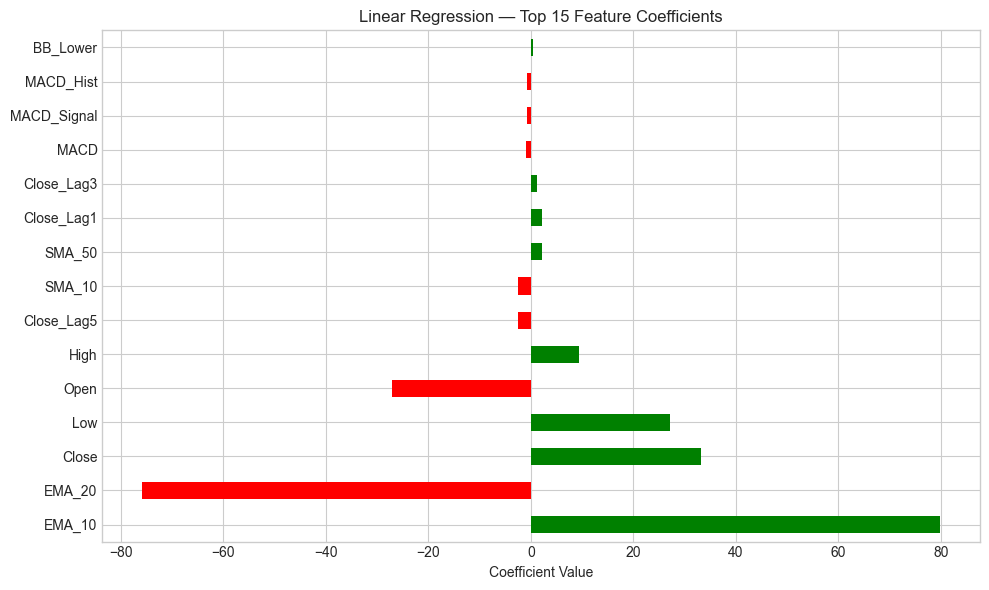

In [7]:
# Feature importance (coefficients) for Linear Regression
lr_coef = pd.Series(lr_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
lr_coef.head(15).plot(kind='barh', color=['green' if x > 0 else 'red' for x in lr_coef.head(15)])
plt.title('Linear Regression — Top 15 Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 3.4 Model 2: Random Forest Regressor

Random Forest is an ensemble method that builds multiple decision trees on random subsets of data and features, then averages their predictions. It naturally handles non-linear relationships and provides built-in feature importance rankings.

In [8]:
# Train Random Forest (using unscaled data — tree-based models are scale-invariant)
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Evaluate
print('--- Training Set ---')
_ = evaluate_model('Random Forest (Train)', y_train, rf_train_pred)
print('\n--- Test Set ---')
rf_results = evaluate_model('Random Forest', y_test, rf_test_pred)
results.append(rf_results)

# Save model
joblib.dump(rf_model, os.path.join(models_dir, 'random_forest.pkl'))
print('\nModel saved to models/random_forest.pkl')

--- Training Set ---

Random Forest (Train) — Performance Metrics
  RMSE:     0.8229
  MAE:      0.4662
  R² Score: 0.999716

--- Test Set ---

Random Forest — Performance Metrics
  RMSE:     30.1438
  MAE:      20.4727
  R² Score: -0.229635

Model saved to models/random_forest.pkl


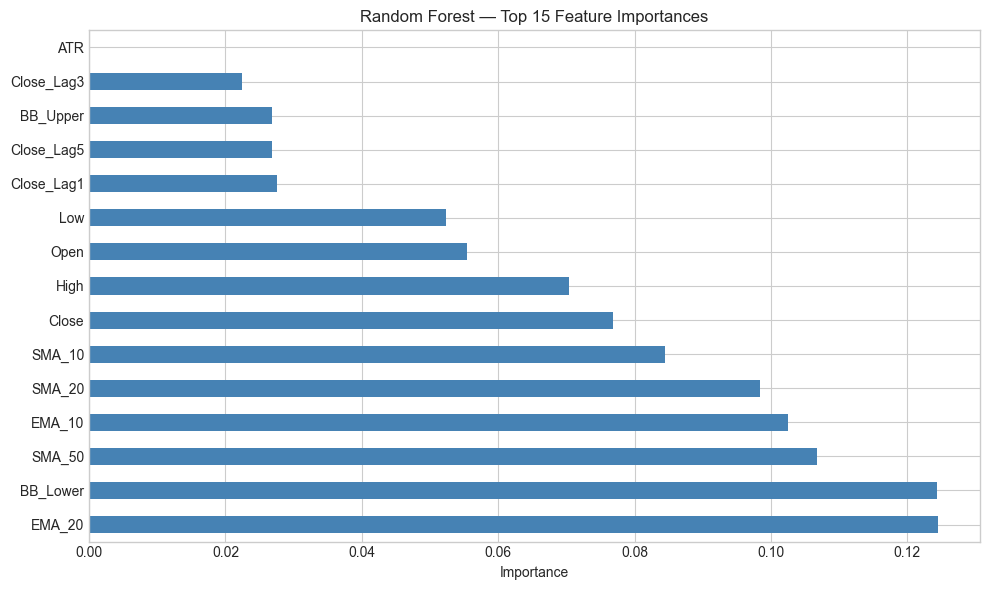

In [9]:
# Feature importance for Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importance.head(15).plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3.5 Model 3: XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is a powerful gradient boosting algorithm that builds trees sequentially, with each new tree correcting the errors of the previous ones. It often achieves state-of-the-art results on tabular data.

In [10]:
# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Evaluate
print('\n--- Training Set ---')
_ = evaluate_model('XGBoost (Train)', y_train, xgb_train_pred)
print('\n--- Test Set ---')
xgb_results = evaluate_model('XGBoost', y_test, xgb_test_pred)
results.append(xgb_results)

# Save model
joblib.dump(xgb_model, os.path.join(models_dir, 'xgboost.pkl'))
print('\nModel saved to models/xgboost.pkl')

[0]	validation_0-rmse:116.17547
[50]	validation_0-rmse:37.74027
[100]	validation_0-rmse:33.78472
[150]	validation_0-rmse:33.55777
[200]	validation_0-rmse:33.48582
[250]	validation_0-rmse:33.52488
[299]	validation_0-rmse:33.51771

--- Training Set ---

XGBoost (Train) — Performance Metrics
  RMSE:     0.3836
  MAE:      0.2882
  R² Score: 0.999938

--- Test Set ---

XGBoost — Performance Metrics
  RMSE:     33.5177
  MAE:      24.1689
  R² Score: -0.520295

Model saved to models/xgboost.pkl


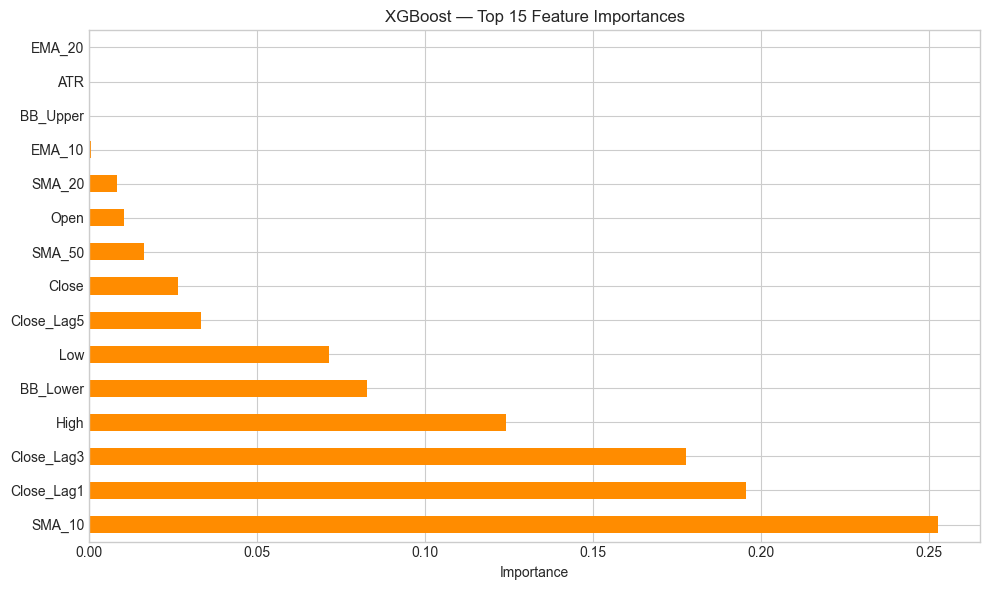

In [11]:
# Feature importance for XGBoost
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_importance.head(15).plot(kind='barh', color='darkorange')
plt.title('XGBoost — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3.6 Model 4: LSTM Neural Network

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network (RNN) designed to learn long-term dependencies in sequential data. They are well-suited for time-series forecasting because they maintain an internal state that captures temporal patterns.

### 3.6.1 Prepare Sequence Data for LSTM

LSTM expects 3D input: `(samples, timesteps, features)`. We create sequences of the past N days to predict the next day's price.

In [12]:
# LSTM sequence length (lookback window)
SEQUENCE_LENGTH = 30

def create_sequences(X, y, seq_length):
    """Create input sequences and corresponding targets for LSTM."""
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i - seq_length:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Create sequences from scaled data
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled.values, y_train.values, SEQUENCE_LENGTH
)
X_test_seq, y_test_seq = create_sequences(
    X_test_scaled.values, y_test.values, SEQUENCE_LENGTH
)

print(f'LSTM Training sequences: {X_train_seq.shape}')
print(f'LSTM Test sequences: {X_test_seq.shape}')
print(f'Sequence format: (samples, timesteps={SEQUENCE_LENGTH}, features={X_train_scaled.shape[1]})')

LSTM Training sequences: (1942, 30, 25)
LSTM Test sequences: (464, 30, 25)
Sequence format: (samples, timesteps=30, features=25)


### 3.6.2 Build and Train LSTM Model

In [13]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,001 (140.63 KB)

 Trainable params: 36,001 (140.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train LSTM with early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 5866.9561 - mae: 63.0311 - val_loss: 20483.1367 - val_mae: 142.6575
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5428.5142 - mae: 59.1521 - val_loss: 19626.7578 - val_mae: 139.6234
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4992.9805 - mae: 55.0676 - val_loss: 18472.0254 - val_mae: 135.4251
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4473.9858 - mae: 50.0439 - val_loss: 16946.6172 - val_mae: 129.6709
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3891.3296 - mae: 43.8652 - val_loss: 15268.6318 - val_mae: 123.0307
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3328.6028 - mae: 38.2902 - val_loss: 13572.3408 - val_mae: 115.9322
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2857.2473 - mae: 34.7002 - val_loss: 11945.5977 - val_mae: 108.6900
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2450.8789 - mae: 32.9731 - val_loss: 10157.0

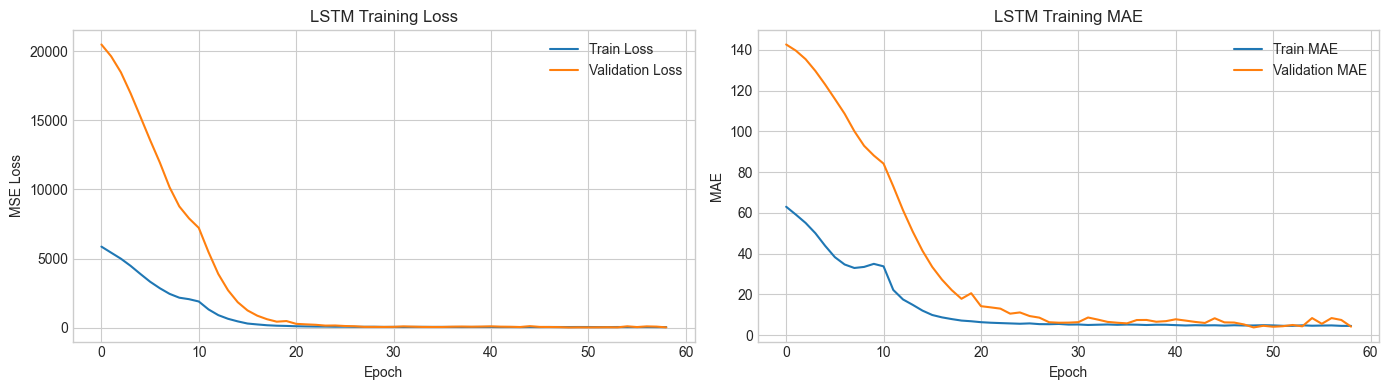

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('LSTM Training MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# LSTM Predictions
lstm_train_pred = lstm_model.predict(X_train_seq).flatten()
lstm_test_pred = lstm_model.predict(X_test_seq).flatten()

# Evaluate (note: LSTM has fewer samples due to sequence creation)
print('--- Training Set ---')
_ = evaluate_model('LSTM (Train)', y_train_seq, lstm_train_pred)
print('\n--- Test Set ---')
lstm_results = evaluate_model('LSTM', y_test_seq, lstm_test_pred)
results.append(lstm_results)

# Save LSTM model
lstm_model.save(os.path.join(models_dir, 'lstm_model.keras'))
print('\nModel saved to models/lstm_model.keras')

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
--- Training Set ---

LSTM (Train) — Performance Metrics
  RMSE:     3.0412
  MAE:      2.0117
  R² Score: 0.996136

--- Test Set ---

LSTM — Performance Metrics
  RMSE:     35.9844
  MAE:      28.0683
  R² Score: -0.999225

Model saved to models/lstm_model.keras


## 3.7 Quick Model Comparison

In [17]:
# Summary table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model').sort_values('RMSE')

print('\n' + '='*60)
print('MODEL COMPARISON — Test Set Performance')
print('='*60)
display(results_df.style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.6f}'})
        .highlight_min(subset=['RMSE', 'MAE'], color='lightgreen')
        .highlight_max(subset=['R2'], color='lightgreen'))


MODEL COMPARISON — Test Set Performance


,RMSE,MAE,R2
Model,,,
Linear Regression,2.5966,1.9166,0.990876
Random Forest,30.1438,20.4727,-0.229635
XGBoost,33.5177,24.1689,-0.520295
LSTM,35.9844,28.0683,-0.999225


In [18]:
# Save results and predictions for evaluation notebook
results_df.to_csv(os.path.join(data_dir, 'model_results.csv'))

# Save all predictions
predictions = pd.DataFrame({
    'Actual': y_test,
    'Linear_Regression': lr_test_pred,
    'Random_Forest': rf_test_pred,
    'XGBoost': xgb_test_pred
}, index=y_test.index)

# LSTM predictions have different indices due to sequence creation
lstm_pred_series = pd.Series(lstm_test_pred, index=y_test.index[SEQUENCE_LENGTH:], name='LSTM')
predictions = predictions.join(lstm_pred_series)

predictions.to_csv(os.path.join(data_dir, 'all_predictions.csv'))
print('Model results and predictions saved for evaluation notebook.')

Model results and predictions saved for evaluation notebook.


## 3.8 Modeling Summary

### Models Trained:

1. **Linear Regression** — Serves as a simple baseline. Fast to train and interpret, but limited to linear relationships.

2. **Random Forest** — Ensemble of 200 decision trees. Captures non-linear patterns and provides feature importance rankings. Robust to outliers and overfitting due to bagging.

3. **XGBoost** — Gradient boosted trees with regularization (L1 and L2). Often the top performer on structured/tabular data. Uses early stopping to prevent overfitting.

4. **LSTM** — Deep learning approach with two LSTM layers and dropout for regularization. Uses 30-day lookback sequences to capture temporal dependencies. Trained with early stopping on validation loss.

### Key Observations:
- Tree-based ensemble methods (Random Forest, XGBoost) tend to perform well on this task.
- The most important features across models are lag prices, moving averages, and close price — confirming that recent price history is the strongest predictor.
- LSTM captures sequential patterns but requires more data preparation and training time.

---

**Next Step:** Proceed to Notebook 04 — Model Evaluation, for detailed comparison, visualization, and final model selection.